In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

In [2]:
df = pd.read_csv('../data/cars.csv')
df

,Unnamed: 0,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,2,164,audi,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,3,2,164,audi,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,4,2,?,audi,gas,std,two,sedan,fwd,front,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,199,-1,95,volvo,gas,std,four,sedan,rwd,front,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
200,200,-1,95,volvo,gas,turbo,four,sedan,rwd,front,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
201,201,-1,95,volvo,gas,std,four,sedan,rwd,front,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
202,202,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [3]:
df.drop(columns=['Unnamed: 0','normalized-losses'],inplace=True)

In [4]:
symbol_pattern = r'[^\w\s]'
for column in df.columns:
    column_text = ' '.join(df[column].astype(str))
    symbols_found = re.findall(symbol_pattern, column_text)
    if symbols_found:
        print(f"Symbols found in column '{column}': {symbols_found}")
    else:
        print(f"No symbols found in column '{column}'")

Symbols found in column 'symboling': ['-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-']
Symbols found in column 'make': ['-', '-', '-', '-', '-', '-', '-', '-', '-', '-']
No symbols found in column 'fuel-type'
No symbols found in column 'aspiration'
Symbols found in column 'num-of-doors': ['?', '?']
No symbols found in column 'body-style'
No symbols found in column 'drive-wheels'
No symbols found in column 'engine-location'
Symbols found in column 'wheel-base': ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.', '.'

In [5]:
mask = df.applymap(lambda x: '?' in str(x))
df[mask] = np.nan

In [6]:
df['price'] = df['price'].astype(float)

In [7]:
df['horsepower'] = df['horsepower'].astype(float)
df['peak-rpm'] = df['peak-rpm'].astype(float)
df['stroke'] = df['stroke'].astype(float)
df['bore'] = df['bore'].astype(float)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          204 non-null    int64  
 1   make               204 non-null    object 
 2   fuel-type          204 non-null    object 
 3   aspiration         204 non-null    object 
 4   num-of-doors       202 non-null    object 
 5   body-style         204 non-null    object 
 6   drive-wheels       204 non-null    object 
 7   engine-location    204 non-null    object 
 8   wheel-base         204 non-null    float64
 9   length             204 non-null    float64
 10  width              204 non-null    float64
 11  height             204 non-null    float64
 12  curb-weight        204 non-null    int64  
 13  engine-type        204 non-null    object 
 14  num-of-cylinders   204 non-null    object 
 15  engine-size        204 non-null    int64  
 16  fuel-system        204 non

In [9]:
df.isnull().sum()

symboling            0
make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 4
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                4
dtype: int64

In [10]:
df['bore'].fillna(int(df['bore'].mean()), inplace=True)
df['stroke'].fillna(int(df['stroke'].mean()), inplace=True)
df['horsepower'].fillna(int(df['horsepower'].mean()), inplace=True)
df['peak-rpm'].fillna(int(df['peak-rpm'].mean()), inplace=True)
df['price'].fillna(int(df['price'].mean()), inplace=True)

In [11]:
df['num-of-doors'].ffill(inplace=True)

In [12]:
df.isnull().sum()

symboling            0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [13]:
print(df.duplicated().sum())
print(df.shape)

0
(204, 25)


<Axes: xlabel='price', ylabel='Density'>

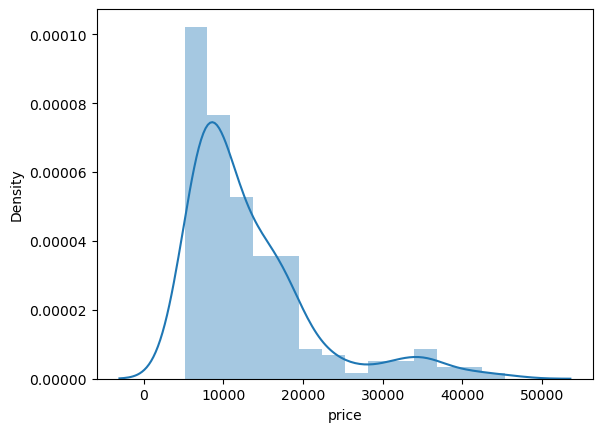

In [14]:
import seaborn as sns
sns.distplot(df['price'])

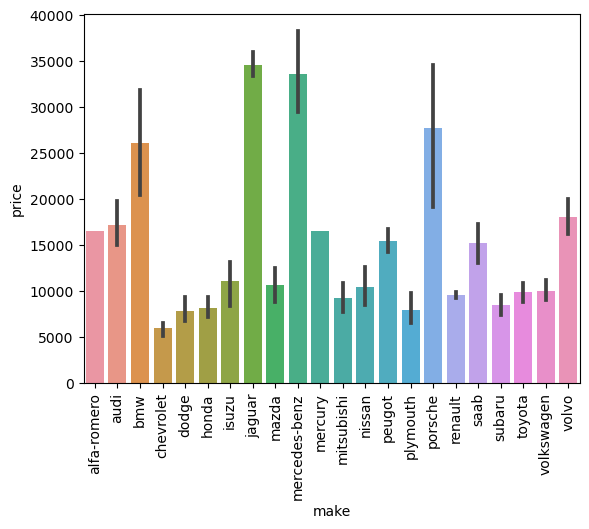

In [15]:
import matplotlib.pyplot as plt
sns.barplot(x=df['make'],y=df['price'])
plt.xticks(rotation='vertical')
plt.show()

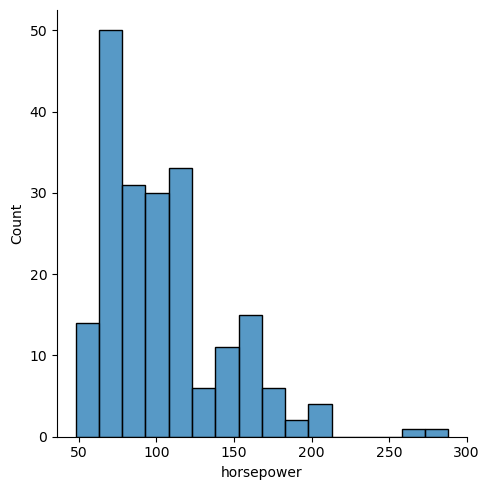

In [16]:
sns.displot(df['horsepower'])

<Axes: xlabel='horsepower', ylabel='price'>

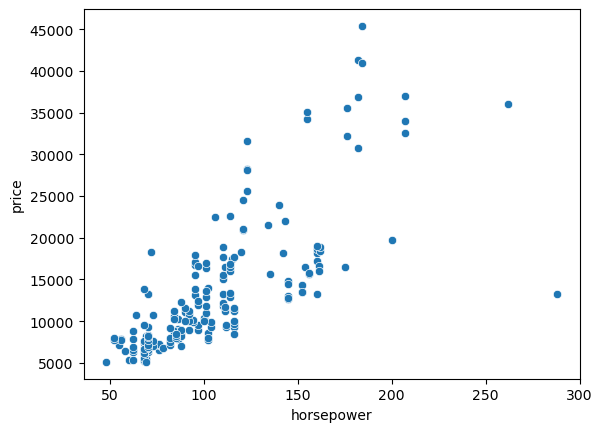

In [17]:
sns.scatterplot(x=df['horsepower'],y=df['price'])

In [18]:
x = df.drop('price', axis = 1)
x

,symboling,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
0,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
1,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26
2,2,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30
3,2,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22
4,2,audi,gas,std,two,sedan,fwd,front,99.8,177.3,...,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,-1,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,four,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28
200,-1,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,four,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25
201,-1,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,six,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23
202,-1,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,six,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27


In [19]:
y = df['price']
y

0      16500.0
1      16500.0
2      13950.0
3      17450.0
4      15250.0
        ...   
199    16845.0
200    19045.0
201    21485.0
202    22470.0
203    22625.0
Name: price, Length: 204, dtype: float64

In [20]:
from sklearn.preprocessing import LabelEncoder
le_x = LabelEncoder()

In [21]:
x = x.apply(le_x.fit_transform)


In [22]:
x

,symboling,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
0,5,0,1,0,1,0,2,0,2,22,...,2,18,5,24,4,13,31,10,8,10
1,3,0,1,0,1,2,2,0,10,29,...,3,28,5,1,28,13,46,10,6,9
2,4,1,1,0,0,3,1,0,30,45,...,2,11,5,14,25,22,27,17,11,13
3,4,1,1,0,0,3,0,0,28,45,...,1,22,5,14,25,5,34,17,5,5
4,4,1,1,0,1,3,1,0,30,47,...,1,22,5,14,25,9,30,17,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,1,21,1,0,0,3,2,0,46,63,...,2,24,5,36,16,20,33,16,10,11
200,1,21,1,1,0,3,2,0,46,63,...,2,24,5,36,16,11,49,15,6,8
201,1,21,1,0,0,3,2,0,46,63,...,3,33,5,27,7,12,39,17,5,6
202,1,21,0,1,0,3,2,0,46,63,...,3,25,3,7,25,31,29,8,13,10


In [23]:
DX = x
DX['price'] = y
DX

,symboling,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,5,0,1,0,1,0,2,0,2,22,...,18,5,24,4,13,31,10,8,10,16500.0
1,3,0,1,0,1,2,2,0,10,29,...,28,5,1,28,13,46,10,6,9,16500.0
2,4,1,1,0,0,3,1,0,30,45,...,11,5,14,25,22,27,17,11,13,13950.0
3,4,1,1,0,0,3,0,0,28,45,...,22,5,14,25,5,34,17,5,5,17450.0
4,4,1,1,0,1,3,1,0,30,47,...,22,5,14,25,9,30,17,6,8,15250.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,1,21,1,0,0,3,2,0,46,63,...,24,5,36,16,20,33,16,10,11,16845.0
200,1,21,1,1,0,3,2,0,46,63,...,24,5,36,16,11,49,15,6,8,19045.0
201,1,21,1,0,0,3,2,0,46,63,...,33,5,27,7,12,39,17,5,6,21485.0
202,1,21,0,1,0,3,2,0,46,63,...,25,3,7,25,31,29,8,13,10,22470.0


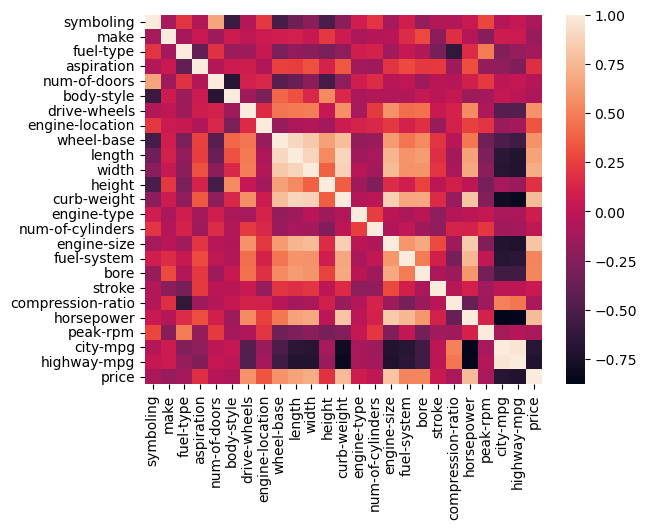

In [24]:
sns.heatmap(DX.corr());

In [25]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
FEATURES = SelectKBest (score_func= f_classif)
FEATURES.fit(x,y)

SelectKBest()

In [26]:
FEATURES.scores_

array([2.0685896 , 1.47275346, 1.65786963, 2.26034976, 2.06656068,
       2.69875994, 1.93449921,        inf, 7.21290601, 3.70993528,
       1.72494385, 3.43633012, 2.19979666, 1.08012719, 3.76994008,
       2.61544243, 2.66643276, 1.54033517, 1.93002064, 1.50949886,
       2.04890496, 5.63606278, 1.35110628, 2.07468548,        inf])

In [27]:
score_col = pd.DataFrame(data = FEATURES.scores_,columns = ['score'])
score_col

,score
0,2.068590
1,1.472753
2,1.657870
3,2.260350
4,2.066561
5,2.698760
6,1.934499
7,inf
8,7.212906
9,3.709935


In [28]:
Name_col=pd.DataFrame(data = x.columns,columns = ['Features'])
Name_col

,Features
0,symboling
1,make
2,fuel-type
3,aspiration
4,num-of-doors
5,body-style
6,drive-wheels
7,engine-location
8,wheel-base
9,length


In [29]:
Features_score=pd.concat([Name_col, score_col], axis=1)
Features_score

,Features,score
0,symboling,2.068590
1,make,1.472753
2,fuel-type,1.657870
3,aspiration,2.260350
4,num-of-doors,2.066561
5,body-style,2.698760
6,drive-wheels,1.934499
7,engine-location,inf
8,wheel-base,7.212906
9,length,3.709935


In [30]:
Features_score.nlargest(10,'score')

,Features,score
7,engine-location,inf
24,price,inf
8,wheel-base,7.212906
21,peak-rpm,5.636063
14,num-of-cylinders,3.769940
9,length,3.709935
11,height,3.436330
5,body-style,2.698760
16,fuel-system,2.666433
15,engine-size,2.615442


In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
from sklearn.metrics import r2_score,mean_absolute_error

In [33]:
from sklearn.model_selection import train_test_split as tts
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.20, random_state=4)
x_train.shape
x_test.shape

(41, 25)

Linear Regression

In [34]:
lr = LinearRegression()

lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
print("r2 Score ",r2_score(y_test,y_pred))
print("MAE Score ",mean_absolute_error(y_test,y_pred))

r2 Score  1.0
MAE Score  2.97249487896518e-12


In [35]:
lr.score(x_test,y_test)

1.0